# CSE422 Lab Project — Hotel Booking Cancellation


## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

Mounted at /content/drive


# Dataset Description

In [3]:
df = pd.read_csv("/content/drive/MyDrive/cse422_Oishowrjyo/11.csv")
print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(df.shape, df.shape[0], df.shape[1]))
df.head()

Shape of the dataset is (119390, 32). This dataset contains 119390 rows and 32 columns.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
numerical_data = df.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:')
count = 1
for i in numerical_features:
    print(f'{count}.', i)
    count += 1
print()

categorical_data = df.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} categorical features:')
count = 1
for i in categorical_features:
    print(f'{count}.', i)
    count += 1

There are 20 numerical features:
1. is_canceled
2. lead_time
3. arrival_date_year
4. arrival_date_week_number
5. arrival_date_day_of_month
6. stays_in_weekend_nights
7. stays_in_week_nights
8. adults
9. children
10. babies
11. is_repeated_guest
12. previous_cancellations
13. previous_bookings_not_canceled
14. booking_changes
15. agent
16. company
17. days_in_waiting_list
18. adr
19. required_car_parking_spaces
20. total_of_special_requests

There are 12 categorical features:
1. hotel
2. arrival_date_month
3. meal
4. country
5. market_segment
6. distribution_channel
7. reserved_room_type
8. assigned_room_type
9. deposit_type
10. customer_type
11. reservation_status
12. reservation_status_date


# Data Analysis

In [9]:
print("Unique Values........")
df.nunique()

Unique Values........


,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [10]:
print("Summary statistics of Numerical Features........")
numerical_data.describe().T

Summary statistics of Numerical Features........


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [11]:
print("Summary statistics of Categorical Features........")
categorical_data.describe().T

Summary statistics of Categorical Features........


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [12]:
print("Variance of each numerical features........")
numerical_data.var()

Variance of each numerical features........


,0
is_canceled,0.233210
lead_time,11419.721511
arrival_date_year,0.500522
arrival_date_week_number,185.099790
arrival_date_day_of_month,77.102966
stays_in_weekend_nights,0.997229
stays_in_week_nights,3.641554
adults,0.335543
children,0.158851
babies,0.009494


In [13]:
print("Skewness Report.....")
skews = numerical_data.skew()

def skewCheck(x):
    if x == 0:
        return "Perfectly symmetrical"
    elif -0.5 <= x <= 0.5:
        return "Fairly symmetrical"
    elif -1 <= x < -0.5 or 0.5 < x <= 1:
        return "Moderately skewed"
    elif x < -1 or x > 1:
        return "Highly skewed"

skewness = pd.DataFrame(skews, columns=["Skewness"])
skewness["Interpretation"] = skewness["Skewness"].apply(skewCheck)
skewness

Skewness Report.....


,Skewness,Interpretation
is_canceled,0.536678,Moderately skewed
lead_time,1.346550,Highly skewed
arrival_date_year,-0.232583,Fairly symmetrical
arrival_date_week_number,-0.010014,Fairly symmetrical
arrival_date_day_of_month,-0.002000,Fairly symmetrical
stays_in_weekend_nights,1.380046,Highly skewed
stays_in_week_nights,2.862249,Highly skewed
adults,18.317805,Highly skewed
children,4.112590,Highly skewed
babies,24.646545,Highly skewed


Plotting Histograms


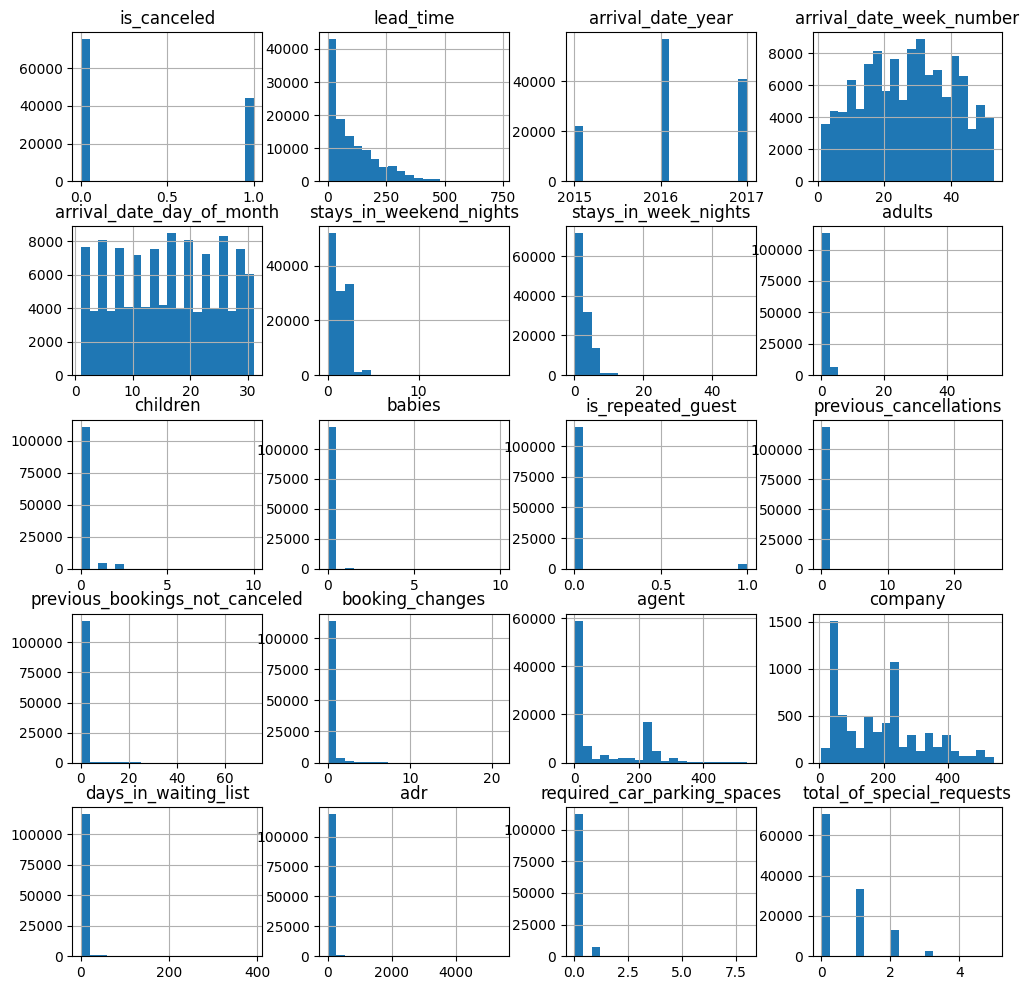

In [14]:
print("Plotting Histograms")
numerical_data.hist(figsize=(12, 12), bins=20)
plt.show()

is_canceled
0    75166
1    44224
Name: count, dtype: int64


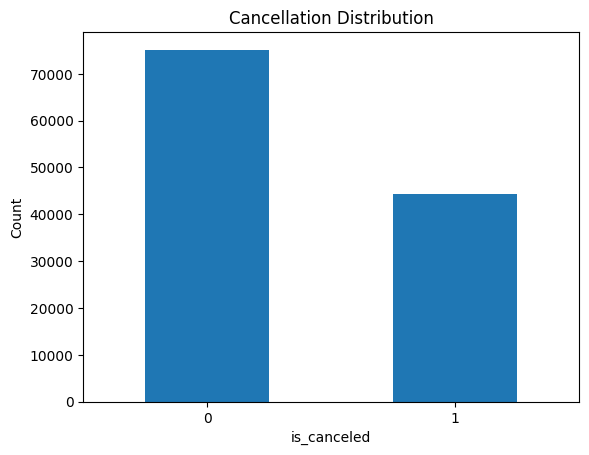

In [15]:
class_counts = df['is_canceled'].value_counts()
print(class_counts)
class_counts.plot(kind='bar', rot=0, xlabel='is_canceled', ylabel='count')
plt.title("Cancellation Distribution")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

In [17]:
# Calculate the correlation matrix
numerical_data.corr()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889


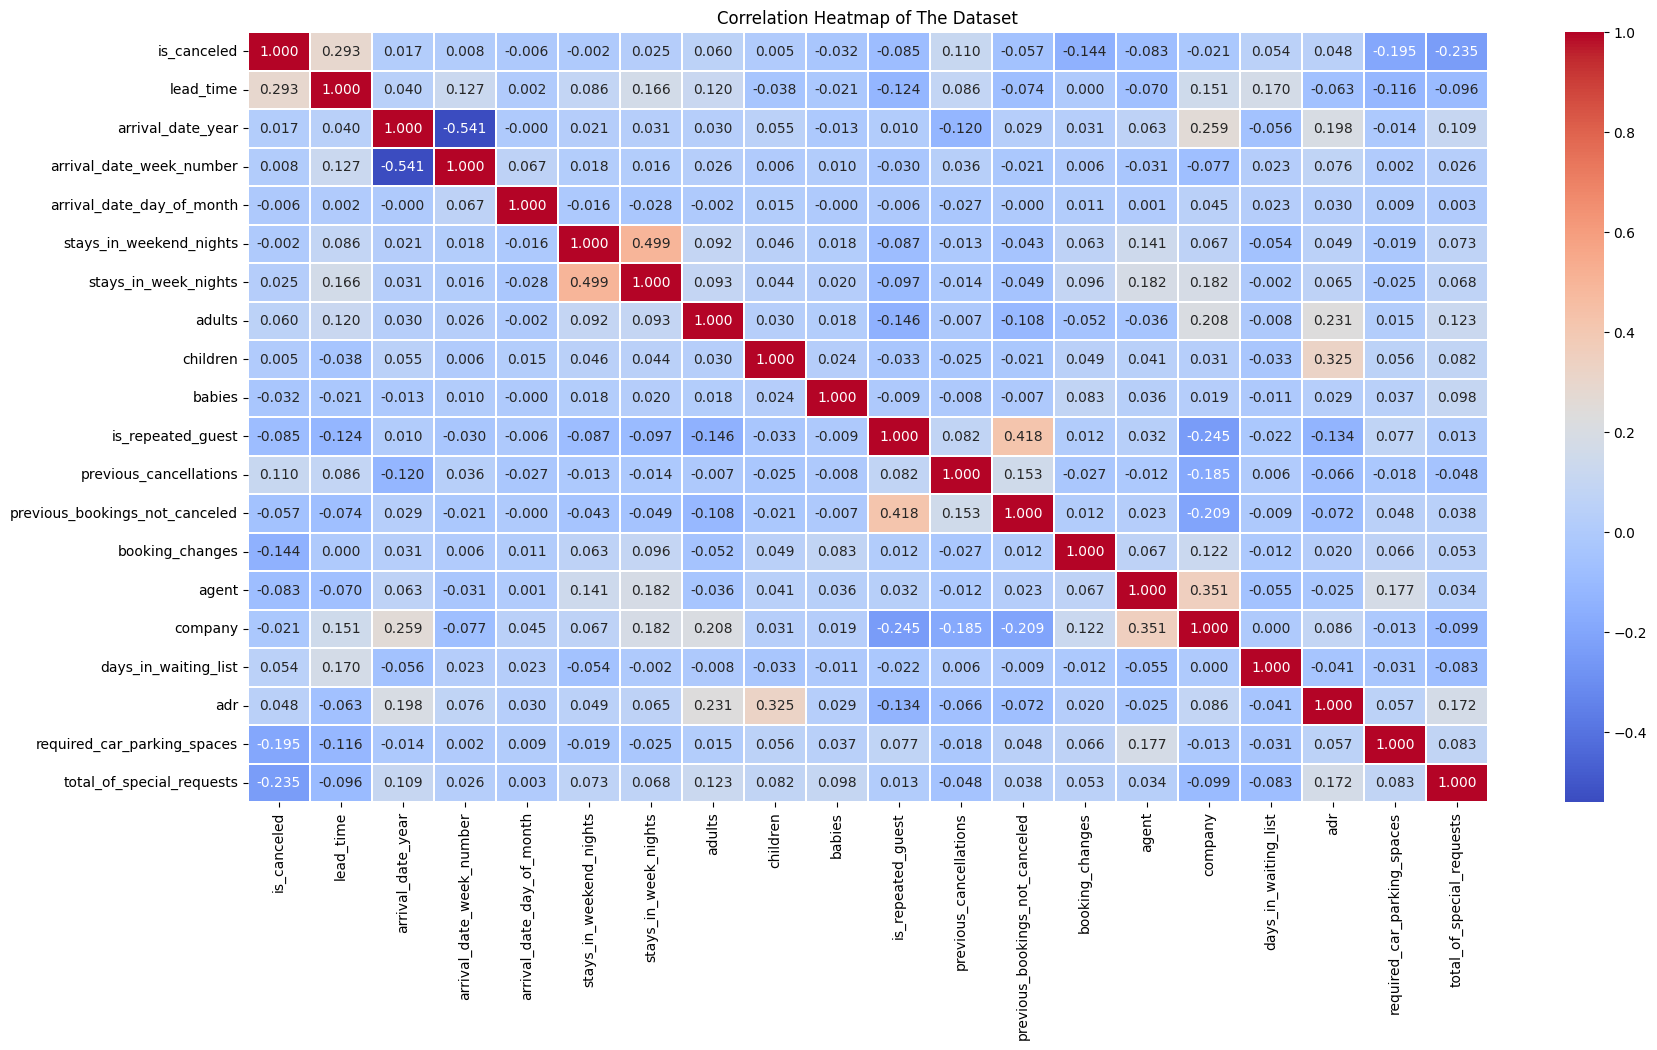

In [16]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.title("Correlation Heatmap of The Dataset")
plt.show()

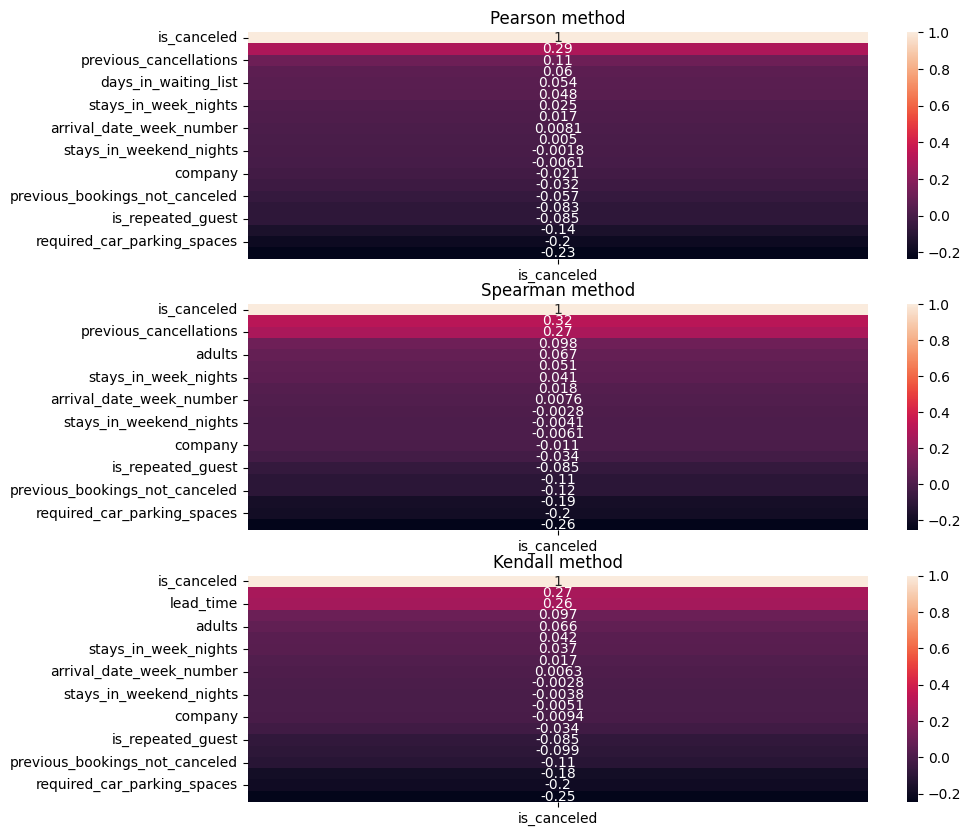

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['is_canceled']].sort_values(by='is_canceled', ascending=False)
corr2 = numerical_data.corr('spearman')[['is_canceled']].sort_values(by='is_canceled', ascending=False)
corr3 = numerical_data.corr('kendall')[['is_canceled']].sort_values(by='is_canceled', ascending=False)

ax[0].set_title('Pearson method')
ax[1].set_title('Spearman method')
ax[2].set_title('Kendall method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

# Dataset Pre-processing

In [19]:
print("Duplicate Values In The Dataset:", df.duplicated().sum())
print("Null Values In The Dataset:")
print(df.isnull().sum())

Duplicate Values In The Dataset: 31994
Null Values In The Dataset:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                   

In [20]:
df.drop_duplicates(inplace=True)
if df.duplicated().sum() == 0:
    print("All Duplicate Values Dropped")

All Duplicate Values Dropped


In [21]:
leak_cols = [c for c in ['reservation_status', 'reservation_status_date'] if c in df.columns]
df.drop(columns=leak_cols, inplace=True)
print("Dropped leakage-prone columns:", leak_cols)
categorical_data = df.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

Dropped leakage-prone columns: ['reservation_status', 'reservation_status_date']


In [22]:
nullL = []
for i in df.columns:
    if df[i].isnull().sum() > 0:
        nullL.append(i)
print("Columns with null values:", nullL)

Columns with null values: ['children', 'country', 'agent', 'company']


In [23]:
print("Performing Null Value Elimination Operations")
for i in nullL:
    if df[i].dtype == 'object':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(0)

count = 0
for i in df.columns:
    if df[i].isnull().sum() > 0:
        count += 1
if count == 0:
    print("All Null Values Eliminated")

Performing Null Value Elimination Operations
All Null Values Eliminated


In [24]:
# Encoding
categorical_cols = categorical_data.columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

is_canceled
0    63371
1    24025
Name: count, dtype: int64


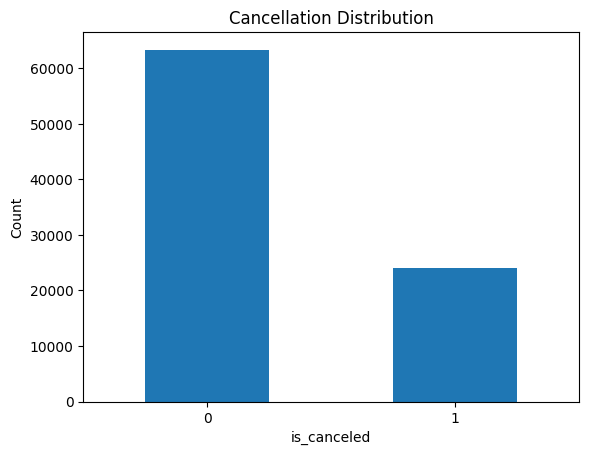

In [25]:
class_counts = df['is_canceled'].value_counts()
print(class_counts)
class_counts.plot(kind='bar', rot=0, xlabel='is_canceled', ylabel='count')
plt.title("Cancellation Distribution")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

In [28]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [29]:
#selection
print("Number of features before feature selection:", X.shape[1])
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
X = X.loc[:, vt.get_support()]
print("Number of features after feature selection:", X.shape[1])


Number of features before feature selection: 247
Number of features after feature selection: 69


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (61177, 69)
X_test : (26219, 69)


In [31]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [32]:
knn = KNeighborsClassifier()
lr = LogisticRegression(max_iter=1000, random_state=42)

models = {
    "KNN": knn,
    "Logistic Regression": lr
}

predictions = {}
probabilities = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=256, validation_split=0.1, verbose=1)

nn_probs = nn_model.predict(X_test_scaled).ravel()
nn_pred = (nn_probs >= 0.5).astype(int)

predictions["Neural Network"] = nn_pred
probabilities["Neural Network"] = nn_probs

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7646 - loss: 0.4820 - val_accuracy: 0.7942 - val_loss: 0.4214
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7966 - loss: 0.4191 - val_accuracy: 0.8102 - val_loss: 0.4001
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8051 - loss: 0.4034 - val_accuracy: 0.8142 - val_loss: 0.3896
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8108 - loss: 0.3942 - val_accuracy: 0.8194 - val_loss: 0.3842
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8154 - loss: 0.3849 - val_accuracy: 0.8236 - val_loss: 0.3793
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8200 - loss: 0.3795 - val_accuracy: 0.8253 - val_loss: 0.3759
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8205 - loss: 0.3760 - val_accuracy: 0.8261 - val_loss: 0.3732
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8233 - loss: 0.3719 - val_accuracy: 0

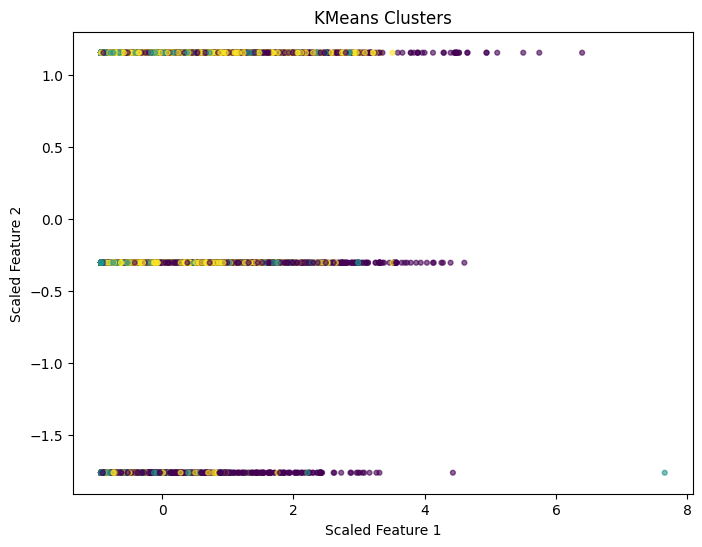

In [33]:
# KMeans Clustering
sample_size = min(10000, len(X_train_scaled))
rng = np.random.RandomState(42)
sample_indices = rng.choice(
    len(X_train_scaled),
    size=sample_size,
    replace=False
)
X_cluster = X_train_scaled[sample_indices]
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_cluster[:, 0],
    X_cluster[:, 1],
    c=cluster_labels,
    s=12,
    alpha=0.6
)
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('KMeans Clusters')
plt.show()

# Model Evaluation

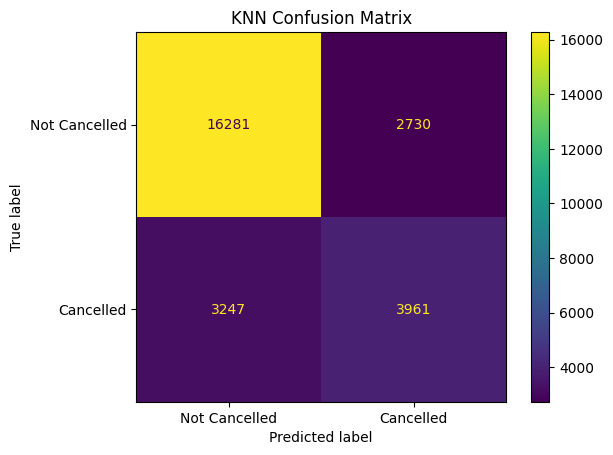

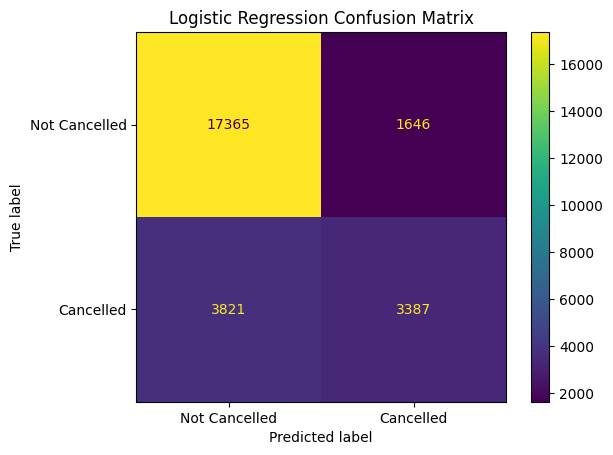

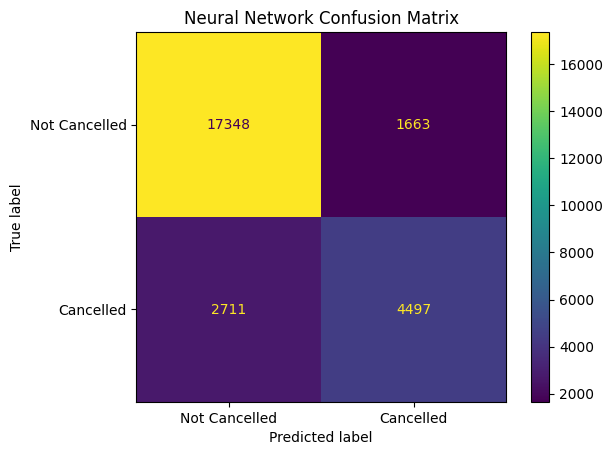

In [34]:
# Confusion Matrix
for name in predictions:
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled', 'Cancelled'])
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [37]:
# Evaluation Metrics
scores = []
for name in predictions:
    y_pred = predictions[name]

    scores.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

scores_df = pd.DataFrame(scores)
scores_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.772036,0.591989,0.549528,0.569969
1,Logistic Regression,0.791487,0.672958,0.469895,0.553386
2,Neural Network,0.833174,0.730032,0.623890,0.672801


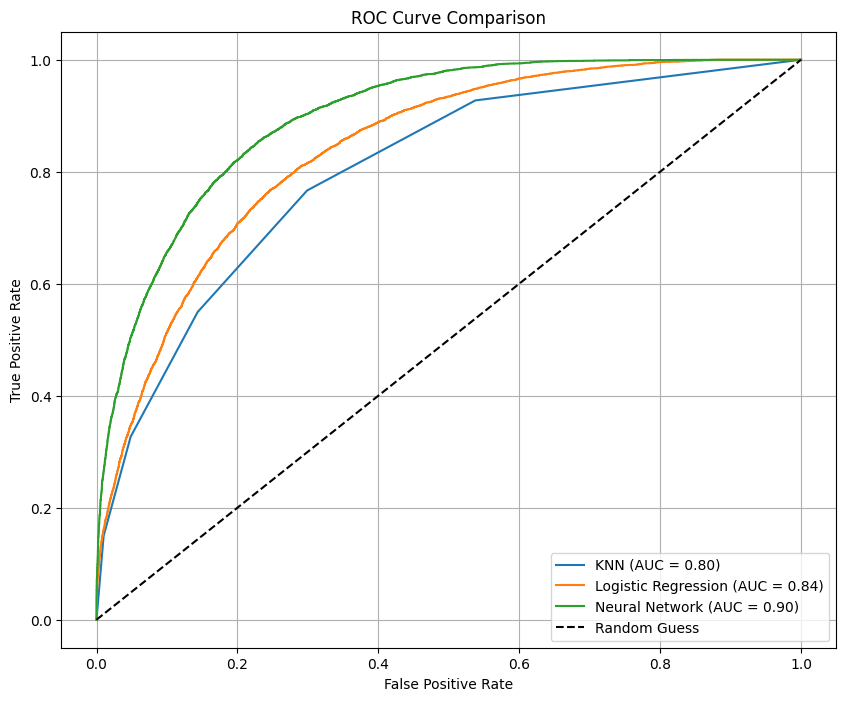

In [38]:
plt.figure(figsize=(10, 8))
for name in probabilities:
    y_probs = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Conclusion & Best Model Selection

In [41]:
auc_list = []
for name in scores_df['Model']:
    y_probs = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_list.append(auc(fpr, tpr))
scores_df['AUC'] = auc_list
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
scores_df['Overall Score'] = scores_df[metrics].mean(axis=1)
print("--- Model Evaluation Summary ---")
scores_df

--- Model Evaluation Summary ---


,Model,Accuracy,Precision,Recall,F1 Score,AUC,Overall Score
0,KNN,0.772036,0.591989,0.549528,0.569969,0.801505,0.657005
1,Logistic Regression,0.791487,0.672958,0.469895,0.553386,0.840369,0.665619
2,Neural Network,0.833174,0.730032,0.623890,0.672801,0.897347,0.751449


In [46]:
print("--- Best Model for Each Metric ---")
for metric in metrics:
    best_idx = scores_df[metric].idxmax()
    best_name = scores_df.loc[best_idx, 'Model']
    best_val = scores_df.loc[best_idx, metric]
    print(f"Best {metric}: {best_name} ({best_val:.4f})")

winner_idx = scores_df['Overall Score'].idxmax()
winner_name = scores_df.loc[winner_idx, 'Model']
winner_score = scores_df.loc[winner_idx, 'Overall Score']
#based on Overall score
print(f"Best Model: {winner_name} ({winner_score:.4f})")

--- Best Model for Each Metric ---
Best Accuracy: Neural Network (0.8332)
Best Precision: Neural Network (0.7300)
Best Recall: Neural Network (0.6239)
Best F1 Score: Neural Network (0.6728)
Best AUC: Neural Network (0.8973)
Best Model: Neural Network (0.7514)
